# AdaBoost
##Implementing AdaBoost on a Dataset
##Model Evaluation, Limitations & Use Cases

---

### Learning Objectives
By the end of this notebook, you will be able to:
- Implement AdaBoost using scikit-learn
- Understand the role of weak learners
- Interpret key parameters of AdaBoost
- Evaluate model performance properly
- Identify when AdaBoost should and should not be used


## 1. Libraries and Tools
We first import all required libraries. Each library is chosen intentionally.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,classification_report

## 2. Loading the Dataset
We use the Breast Cancer dataset because it is clean, binary, and well-suited for demonstrating boosting behavior.

In [ ]:
x,y=load_breast_cancer(return_X_y=True)
print("Feature matrix shape: ",x.shape)
print("Target Vector shape: ",y.shape)

Feature matrix shape:  (569, 30)
Target Vector shape:  (569,)


## 3. Train-Test Split
We split the dataset so that evaluation is fair and unbiased.

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
print('Training Samples: ',x_train.shape[0])
print('Testing Samples: ',x_test.shape[0])

Training Samples:  426
Testing Samples:  143


## 4. Baseline Model: Decision Stump
Before boosting, we examine how a single weak learner performs.

In [ ]:
stump=DecisionTreeClassifier(max_depth=1,random_state=42)
stump.fit(x_train,y_train)
y_pred_stump=stump.predict(x_test)
print("Decision Tree Stump Accuracy: ",accuracy_score(y_test,y_pred_stump))

Decision Tree Stump Accuracy:  0.8951048951048951


## 5. Building AdaBoost Model
Now we boost the weak learner using AdaBoost.

In [ ]:
#Building AdaBoost Model
base_learner=DecisionTreeClassifier(max_depth=1,random_state=42)
adaboost=AdaBoostClassifier(estimator=base_learner,n_estimators=20,learning_rate=0.3,random_state=42)
adaboost.fit(x_train,y_train)
y_pred_adaboost=adaboost.predict(x_test)
print("AdaBoost Accuracy: ",accuracy_score(y_test,y_pred_adaboost))

AdaBoost Accuracy:  0.965034965034965


**AdaBoostClassifier**

class sklearn.ensemble.AdaBoostClassifier(estimator=None, *, n_estimators=50, learning_rate=1.0, random_state=None)

**Parameters:**
* estimator: object, default=None

The base estimator from which the boosted ensemble is built. Support for sample weighting is required, as well as proper classes_ and n_classes_ attributes. If None, then the base estimator is DecisionTreeClassifier initialized with max_depth=1.

* n_estimatorsint, default=50

The maximum number of estimators at which boosting is terminated. In case of perfect fit, the learning procedure is stopped early. Values must be in the range [1, inf).

* learning_rate: float, default=1.0

Weight applied to each classifier at each boosting iteration. A higher learning rate increases the contribution of each classifier. There is a trade-off between the learning_rate and n_estimators parameters. Values must be in the range (0.0, inf).

* random_state: int, RandomState instance or None, default=None

Controls the random seed given at each estimator at each boosting iteration. Thus, it is only used when estimator exposes a random_state. Pass an int for reproducible output across multiple function calls

## 7. Detailed Evaluation
Accuracy alone is not enough. We use additional metrics.

In [ ]:
print(classification_report(y_test,y_pred_adaboost))
print("Confusion Matrix :\n",confusion_matrix(y_test,y_pred_adaboost))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.97      0.98      0.97        89

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143

Confusion Matrix :
 [[51  3]
 [ 2 87]]


## 8. Effect of Number of Estimators
We now observe how the number of weak learners affects performance.

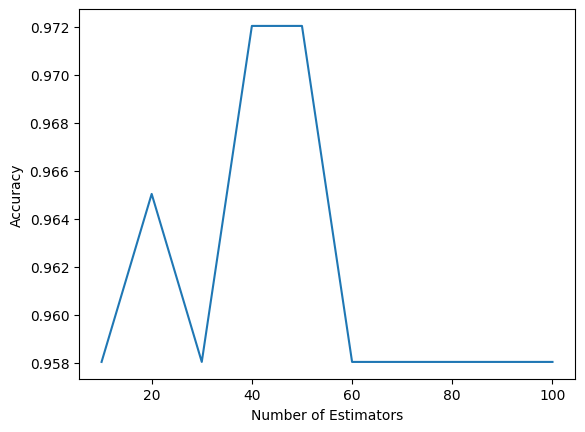

In [ ]:
#Effect of Number of Estimators
estimator=[10,20,30,40,50,60,70,80,90,100]
accuracy=[]
for i in estimator:
  adaboost=AdaBoostClassifier(estimator=base_learner,n_estimators=i,learning_rate=0.3,random_state=42)
  adaboost.fit(x_train,y_train)
  y_pred_adaboost=adaboost.predict(x_test)
  accuracy.append(accuracy_score(y_test,y_pred_adaboost))
plt.plot(estimator,accuracy)
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.show('Effect of n_estimators')
plt.show()

## 9. Effect of Learning Rate
Learning rate controls how strongly each learner contributes.

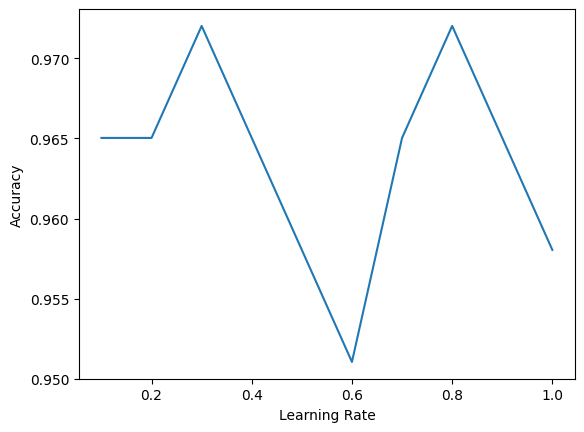

In [ ]:
#Effect of Learning rate
estimator=[0.1 ,0.2,0.3,0.5,0.6,0.7,0.8,0.9,1]
accuracy=[]
for i in estimator:
  adaboost=AdaBoostClassifier(estimator=base_learner,n_estimators=50,learning_rate=i,random_state=42)
  adaboost.fit(x_train,y_train)
  y_pred_adaboost=adaboost.predict(x_test)
  accuracy.append(accuracy_score(y_test,y_pred_adaboost))
plt.plot(estimator,accuracy)
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.show('Effect of n_estimators')
plt.show()

## 10. GridSearchCV (Optional)
We can try to find the optimal parameters through GridSearchCV here.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Parameter grid for AdaBoost
param_grid = {
    'n_estimators': [20, 50, 100, 200],
    'learning_rate': [0.1, 0.3, 0.5, 0.7, 1.0],
    'estimator__max_depth': [1, 2]
}

# GridSearchCV setup
grid = GridSearchCV(
    estimator=AdaBoostClassifier(
        estimator=base_learner,
        random_state=42
    ),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Run grid search
grid.fit(x_train, y_train)

# Best model evaluation
best_model = grid.best_estimator_
y_pred_grid = best_model.predict(x_test)

print("Best Parameters Found:")
print(grid.best_params_)
print("\nTest Accuracy (GridSearch AdaBoost):",
      accuracy_score(y_test, y_pred_grid))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_grid))

Best Parameters Found:
{'estimator__max_depth': 1, 'learning_rate': 1.0, 'n_estimators': 200}

Test Accuracy (GridSearch AdaBoost): 0.9790209790209791

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        54
           1       0.99      0.98      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



## 11. Limitations and Use Cases
AdaBoost performs well on clean data but struggles with heavy noise and outliers.

### Changes you can try
1. Change max_depth to 3-6 and observe results
2. Combine low learning rate with high estimators
3. Compare AdaBoost with a full decision tree and Random Forest
